# Csomagok letöltése

In [2]:
pip install numpy Cython

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 22.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install wheel


Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install git+https://github.com/CPJKU/madmom.git

  Cloning https://github.com/CPJKU/madmom.git to C:\Users\Béres Gábor\AppData\Local\Temp\pip-req-build-gbkwhp1u
  Resolved https://github.com/CPJKU/madmom.git to commit 27f032e8947204902c675e5e341a3faf5dc86dae
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached mido-1.3.3-py3-none-any.whl.metadata (6.4 kB)
Using cached mido-1.3.3-py3-none-any.whl (54 kB)
  Created wheel for madmom: filename=madmom-0.17.dev0-cp312-cp312-win_amd64.whl size=24438922 sha256=a7d8750df69f329fced05dd0f0e2cd32d1099d2cf998e1f6d174ae13ad66633a
  Stored in directory: C:\Users\Béres Gábor\AppData\Local\Temp\pip-ephem-wheel

  Running command git clone --filter=blob:none --quiet https://github.com/CPJKU/madmom.git 'C:\Users\Béres Gábor\AppData\Local\Temp\pip-req-build-gbkwhp1u'
  Running command git submodule update --init --recursive -q


In [13]:
import numpy as np
from madmom.features.chords import CNNChordFeatureProcessor, CRFChordRecognitionProcessor

# --- 1. SZÓTÁR: Szöveges akkordok konvertálása 0-23 indexekre ---
# 0-11: Dúr akkordok (:maj), 12-23: Moll akkordok (:min)
CHORD_MAP = {
    'C:maj': 0, 'C#:maj': 1, 'D:maj': 2, 'D#:maj': 3, 'E:maj': 4, 'F:maj': 5, 'F#:maj': 6, 'G:maj': 7, 'G#:maj': 8, 'A:maj': 9, 'A#:maj': 10, 'B:maj': 11,
    'C:min': 12, 'C#:min': 13, 'D:min': 14, 'D#:min': 15, 'E:min': 16, 'F:min': 17, 'F#:min': 18, 'G:min': 19, 'G#:min': 20, 'A:min': 21, 'A#:min': 22, 'B:min': 23,
    
    # Biztonsági tartalék, ha valamiért sima betűt adna vissza:
    'C': 0, 'C#': 1, 'D': 2, 'D#': 3, 'E': 4, 'F': 5, 'F#': 6, 'G': 7, 'G#': 8, 'A': 9, 'A#': 10, 'B': 11
}

def create_chord_transition_matrix(audio_file_path):
    print(f"Feldolgozás alatt: {audio_file_path}")
    
    # 1. Jellemzőkinyerés és Akkordfelismerés a Madmom-mal
    feat_processor = CNNChordFeatureProcessor()
    chord_processor = CRFChordRecognitionProcessor()
    
    features = feat_processor(audio_file_path)
    chords_output = chord_processor(features)

    print(f"Kinyert akkordok száma: {(chords_output)}")
    
    # 2. Csak a zenei akkordok kinyerése és konvertálása számokra
    # A Madmom 'N' betűvel jelöli, ha nincs akkord (csend/dob). Ezt kihagyjuk a mátrixból.
    numeric_sequence = []
    for start, end, label in chords_output:
        if label != 'N' and label in CHORD_MAP:
            numeric_sequence.append(CHORD_MAP[label])
            print(f"Akkord: {label} -> Index: {CHORD_MAP[label]}")
            
    # 3. Redundancia szűrése (összevonjuk az egymás utáni azonos akkordokat)
    if not numeric_sequence:
        return np.zeros((24, 24))
        
    compressed_seq = [numeric_sequence[0]]
    for chord in numeric_sequence[1:]:
        if chord != compressed_seq[-1]:
            compressed_seq.append(chord)
            
    # 4. Mátrix inicializálása és feltöltése (Laplace simítással a 0-val osztás ellen)
    transition_matrix = np.zeros((24, 24)) + 1e-5
    
    for i in range(len(compressed_seq) - 1):
        current_chord = compressed_seq[i]
        next_chord = compressed_seq[i + 1]
        transition_matrix[current_chord, next_chord] += 1
        
    # 5. Normalizálás (valószínűségek százalékosítása soronként)
    row_sums = transition_matrix.sum(axis=1, keepdims=True)
    transition_matrix = transition_matrix / row_sums
    
    return transition_matrix

# --- PRÓBÁLJUK KI EGY ZENÉDDEL! ---
if __name__ == "__main__":
    # Írd ide az egyik 30 másodperces zenéd pontos nevét
    test_audio = "../MP3/Lose Control (feat. Ciara & Fat Man Scoop) - Missy Elliott.mp3"
    
    # Mátrix generálása
    song_matrix = create_chord_transition_matrix(test_audio)
    
    # Vektorrá alakítás az ajánlórendszerhez (576 elemű ujjlenyomat)
    song_fingerprint = song_matrix.flatten()
    
    print("\nKész a dal ujjlenyomata!")
    print(f"A vektor hossza: {len(song_fingerprint)} szám.")
    print(f"Az első 10 érték: {song_fingerprint[:10]}")

    #Teljes mátrix megjelenítése grafikus formában (opcionális)
    print("\nA teljes akkord átmeneti mátrix:")
    print(song_matrix)

Feldolgozás alatt: ../MP3/Lose Control (feat. Ciara & Fat Man Scoop) - Missy Elliott.mp3
Kinyert akkordok száma: [( 0. ,  5.2, 'N') ( 5.2,  6.2, 'F:maj') ( 6.2, 13.4, 'N')
 (13.4, 14.5, 'F#:maj') (14.5, 18.9, 'N') (18.9, 20.4, 'F#:maj')
 (20.4, 29.8, 'N')]
Akkord: F:maj -> Index: 5
Akkord: F#:maj -> Index: 6
Akkord: F#:maj -> Index: 6

Kész a dal ujjlenyomata!
A vektor hossza: 576 szám.
Az első 10 érték: [0.04166667 0.04166667 0.04166667 0.04166667 0.04166667 0.04166667
 0.04166667 0.04166667 0.04166667 0.04166667]

A teljes akkord átmeneti mátrix:
[[4.16666667e-02 4.16666667e-02 4.16666667e-02 4.16666667e-02
  4.16666667e-02 4.16666667e-02 4.16666667e-02 4.16666667e-02
  4.16666667e-02 4.16666667e-02 4.16666667e-02 4.16666667e-02
  4.16666667e-02 4.16666667e-02 4.16666667e-02 4.16666667e-02
  4.16666667e-02 4.16666667e-02 4.16666667e-02 4.16666667e-02
  4.16666667e-02 4.16666667e-02 4.16666667e-02 4.16666667e-02]
 [4.16666667e-02 4.16666667e-02 4.16666667e-02 4.16666667e-02
  4.166666

In [14]:
pip install seaborn matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -------- ------------------------------- 2

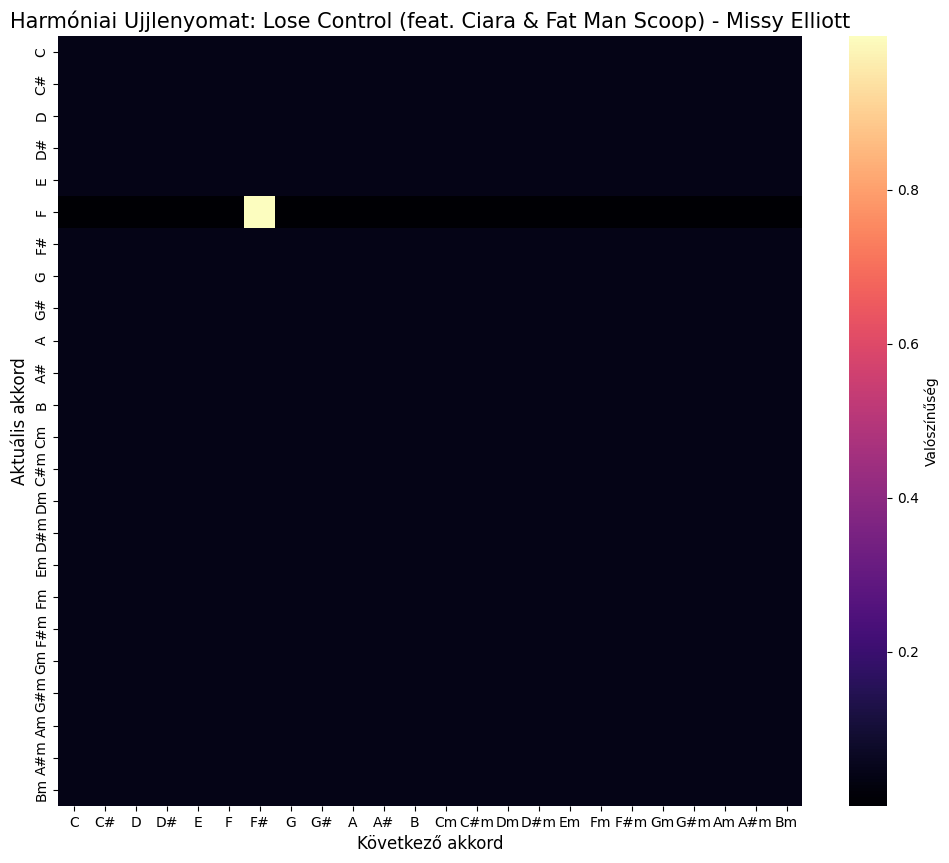

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_chord_heatmap(matrix, song_title="Dal akkord átmenetei"):
    # Akkord nevek a tengelyekre (ugyanaz a sorrend, mint a CHORD_MAP-ben)
    labels = [
        'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B',
        'Cm', 'C#m', 'Dm', 'D#m', 'Em', 'Fm', 'F#m', 'Gm', 'G#m', 'Am', 'A#m', 'Bm'
    ]

    plt.figure(figsize=(12, 10))
    
    # Heatmap létrehozása
    # annot=False: ne írja bele a számokat minden kockába (túl zsúfolt lenne)
    # cmap="YlGnBu": Sárga-Zöld-Kék színskála (vagy próbáld ki a "magma"-t)
    ax = sns.heatmap(matrix, xticklabels=labels, yticklabels=labels, 
                     cmap="magma", annot=False, cbar_kws={'label': 'Valószínűség'})

    plt.title(f"Harmóniai Ujjlenyomat: {song_title}", fontsize=15)
    plt.xlabel("Következő akkord", fontsize=12)
    plt.ylabel("Aktuális akkord", fontsize=12)
    
    plt.show()

# Használat:
plot_chord_heatmap(song_matrix, "Lose Control (feat. Ciara & Fat Man Scoop) - Missy Elliott")

# Features/markov_chrods dataset létrehozása

In [3]:
import h5py
import numpy as np
import os

DATASET_DIR = "../Dataset/"
OUTPUT_FILE = os.path.join(DATASET_DIR, "spotify_dataset_compressed.h5")
with h5py.File(OUTPUT_FILE, "a") as hf:
    if "features" not in hf:
        feat_grp = hf.create_group("features")
        print("✅ '/features' group létrehozva.")
    else:
        feat_grp = hf["features"]
        print("ℹ️ '/features' group már létezik.")

    if "markov_chords" not in feat_grp:
        feat_grp.create_dataset("markov_chords", shape=(0, 576), maxshape=(None, 576),
                                dtype=np.float32, chunks=(1000, 576), compression="lzf")
        print("✅ 'markov_chords' dataset létrehozva.")


ℹ️ '/features' group már létezik.
✅ 'markov_chords' dataset létrehozva.


In [2]:
import h5py
import os

H5_PATH = "../Dataset/spotify_dataset_compressed.h5"

def delete_dataset(dataset_path):
    print(f"HDF5 fájl megnyitása: {H5_PATH}")
    
    # "a" (append) módban nyitjuk meg, hogy módosíthassuk
    with h5py.File(H5_PATH, "a") as hf:
        if dataset_path in hf:
            del hf[dataset_path]
            print(f"✅ A '{dataset_path}' sikeresen törölve lett a fájlból!")
        else:
            print(f"ℹ️ A '{dataset_path}' nem is létezik, nincs mit törölni.")

if __name__ == "__main__":
    # Írd ide a pontos útvonalat, amit törölni akarsz
    delete_dataset("features/markov_chords")

HDF5 fájl megnyitása: ../Dataset/spotify_dataset_compressed.h5
✅ A 'features/markov_chords' sikeresen törölve lett a fájlból!


# Első 100 dal teszt, betöltjük a hdf5-be

In [1]:
pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   --------------------- ---------------- 524.3/914.9 kB 262.1 kB/s eta 0:00:02
   ---------------------------------------- 914.9/914.9 kB 580.2 kB/s  0:00:01
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 5.6 MB/s eta 0:00:01
   -------------- ------------------------- 0.8

In [ ]:
import os
import sys
import json
import h5py
import numpy as np
import concurrent.futures
from tqdm.notebook import tqdm  # Notebook-kompatibilis progress bar

# ⚠️ Windows spawn mód miatt a worker függvények csak importált .py-ból működnek
sys.path.insert(0, os.getcwd())
from chord_processor import init_worker, process_single_track

H5_PATH   = "../Dataset/spotify_dataset_compressed.h5"
MP3_DIR   = "../MP3/"
CHECKPOINT_PATH = "chord_checkpoint.json"
MAX_WORKERS = 12
BATCH_SIZE  = 500

# --- 1. Metaadatok ---
print("Metaadatok beolvasása...")
with h5py.File(H5_PATH, "r") as hf:
    t_uris  = hf["tracks/track_uri"][:]
    t_names = hf["tracks/track_name"][:]
    a_names = hf["tracks/artist_name"][:]
    ml_uris = hf["ml/track_uri"][:]

track_info_dict = {}
for i in range(len(t_uris)):
    uri    = t_uris[i].decode('utf-8') if isinstance(t_uris[i], bytes) else t_uris[i]
    name   = t_names[i].decode('utf-8') if isinstance(t_names[i], bytes) else t_names[i]
    artist = a_names[i].decode('utf-8') if isinstance(a_names[i], bytes) else a_names[i]
    track_info_dict[uri] = (name, artist)

total = len(ml_uris)
print(f"Összes dal: {total}")

# --- 2. Task lista ---
all_tasks = []
for i in range(total):
    ml_uri = ml_uris[i].decode('utf-8') if isinstance(ml_uris[i], bytes) else ml_uris[i]
    if ml_uri in track_info_dict:
        t_name, a_name = track_info_dict[ml_uri]
        safe_name = (
            f"{t_name} - {a_name}"
            .replace('/', '-').replace('\\', '-').replace(':', '-')
            .replace('*', '-').replace('?', '-').replace('"', '-')
            .replace('<', '-').replace('>', '-').replace('|', '-')
        )
        all_tasks.append((i, os.path.join(MP3_DIR, f"{safe_name}.mp3")))
    else:
        all_tasks.append((i, "NOT_FOUND"))

# --- 3. Checkpoint betöltése ---
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, "r") as f:
        done_indices = set(json.load(f)["done_indices"])
    print(f"Checkpoint betöltve: {len(done_indices)} dal már kész.")
else:
    done_indices = set()

pending_tasks = [t for t in all_tasks if t[0] not in done_indices]
print(f"Feldolgozandó: {len(pending_tasks)} dal")

# --- 4. H5 méret ellenőrzés ---
with h5py.File(H5_PATH, "r+") as hf:
    dset = hf["features/markov_chords"]
    if dset.shape[0] < total:
        dset.resize((total, 576))

# --- 5. Batch-enkénti feldolgozás ---
num_batches = -(-len(pending_tasks) // BATCH_SIZE)  # ceiling division

overall_bar = tqdm(total=len(pending_tasks), desc="🎵 Összes dal", unit="dal")

for batch_idx in range(0, len(pending_tasks), BATCH_SIZE):
    batch = pending_tasks[batch_idx : batch_idx + BATCH_SIZE]
    batch_results = {}
    current_batch_num = batch_idx // BATCH_SIZE + 1

    with concurrent.futures.ProcessPoolExecutor(
        max_workers=MAX_WORKERS, initializer=init_worker
    ) as executor:
        futures = {executor.submit(process_single_track, task): task for task in batch}
        for future in concurrent.futures.as_completed(futures):
            try:
                index, result_vector = future.result()
                batch_results[index] = result_vector
            except Exception as e:
                task = futures[future]
                batch_results[task[0]] = np.zeros(576, dtype=np.float32)
            overall_bar.update(1)

    # H5 írás
    with h5py.File(H5_PATH, "r+") as hf:
        dset = hf["features/markov_chords"]
        for index, vector in batch_results.items():
            dset[index] = vector

    # Checkpoint mentés
    done_indices.update(batch_results.keys())
    with open(CHECKPOINT_PATH, "w") as f:
        json.dump({"completed": len(done_indices), "done_indices": list(done_indices)}, f)
    overall_bar.set_postfix({"mentve": len(done_indices), "batch": f"{current_batch_num}/{num_batches}"})

overall_bar.close()

if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)

print("✅ Minden dal feldolgozva és mentve!")

Metaadatok beolvasása...
Összes dal: 27052
Feldolgozandó: 27052 dal


🎵 Összes dal:   0%|          | 0/27052 [00:00<?, ?dal/s]

# Sablon alapú akkord számítás 

In [23]:
import numpy as np
import h5py
from tqdm.notebook import tqdm

# --- PARAMÉTEREK ÉS ÚTVONALAK ---
H5_FILE = "../Dataset/spotify_dataset_compressed.h5"

def normalize_to_c(chord_seq):
    """
    Egy 0-23 közötti akkordsorozatot (0-11 Dúr, 12-23 Moll) transzponál úgy, 
    hogy a dal alaphangneme (a leggyakoribb akkord) C (0) vagy Cm (12) legyen.
    """
    if len(chord_seq) == 0:
        return chord_seq
        
    # 1. Melyik a leggyakoribb akkord? (Feltételezzük, hogy ez a hangnem)
    counts = np.bincount(chord_seq, minlength=24)
    tonic_idx = np.argmax(counts)
    
    root_note = tonic_idx % 12  # A gyökérhang (0=C, 1=C#, ..., 11=B)
    
    # 2. Kiszámoljuk az eltolást (mennyit kell lépni, hogy C legyen)
    shift = (0 - root_note) % 12
    
    # 3. Eltolás alkalmazása minden akkordra
    normalized_seq = np.zeros_like(chord_seq)
    
    # Külön kezeljük a dúr és moll akkordokat, hogy a saját tartományukban maradjanak
    is_minor = chord_seq >= 12
    
    # Dúr akkordok eltolása (0-11 tartományban pörögnek körbe)
    normalized_seq[~is_minor] = (chord_seq[~is_minor] + shift) % 12
    
    # Moll akkordok eltolása (12-23 tartományban pörögnek körbe)
    normalized_seq[is_minor] = ((chord_seq[is_minor] - 12 + shift) % 12) + 12
    
    return normalized_seq

def run_markov_generation(hdf5_path):
    # 1. Sablonok létrehozása (24 akkord x 12 hang)
    templates = np.zeros((24, 12), dtype=np.float32)
    for i in range(12):
        templates[i, [i, (i + 4) % 12, (i + 7) % 12]] = 1.0 # Dúr
        templates[i + 12, [i, (i + 3) % 12, (i + 7) % 12]] = 1.0 # Moll
    
    templates /= (np.linalg.norm(templates, axis=1, keepdims=True) + 1e-8)

    with h5py.File(hdf5_path, "r+") as hf:
        if "spectrograms/chroma" not in hf:
            print("❌ Hiba: Nem találom a 'spectrograms/chroma' datasetet!")
            return
            
        chroma_ds = hf["spectrograms/chroma"]
        total_tracks = chroma_ds.shape[0]

        # 2. DATASET ELLENŐRZÉSE ÉS ÁTMÉRETEZÉSE
        if "features/markov_chords" not in hf:
            # Ha még nincs, létrehozzuk a teljes méretben
            hf.create_dataset("features/markov_chords", 
                              shape=(total_tracks, 576), 
                              maxshape=(None, 576), # Hogy később is bővíthető legyen
                              dtype=np.float32)
            print("✅ 'features/markov_chords' létrehozva.")
        
        markov_ds = hf["features/markov_chords"]

        # --- ITT A JAVÍTÁS ---
        # Ha a dataset létezik, de 0 soros vagy kisebb, mint kellene, átméretezzük
        if markov_ds.shape[0] < total_tracks:
            print(f"🔄 Dataset átméretezése: {markov_ds.shape[0]} -> {total_tracks} sorra...")
            markov_ds.resize((total_tracks, 576))
        # --------------------

        print(f"🚀 Feldolgozás indítása: {total_tracks} dal...")

        for i in tqdm(range(total_tracks), desc="Akkord-analízis"):
            chroma = chroma_ds[i]
            
            # Időpillanatonkénti normalizálás
            norm = np.linalg.norm(chroma, axis=0, keepdims=True) + 1e-8
            chroma_n = chroma / norm
            
            # Sablonillesztés
            sims = np.dot(templates, chroma_n)
            
            # Akkord sorozat és váltások
            chord_seq = np.argmax(sims, axis=0)

            chord_seq = normalize_to_c(chord_seq)

            changes = chord_seq[np.insert(np.diff(chord_seq) != 0, 0, True)]
            
            # Markov-mátrix építése
            m = np.zeros((24, 24), dtype=np.float32) + 1e-5
            
            if len(changes) > 1:
                for current, next_chord in zip(changes[:-1], changes[1:]):
                    m[current, next_chord] += 1
            
            m /= m.sum(axis=1, keepdims=True)
            
            # Mentés - Most már nem fog hibát dobni!
            markov_ds[i] = m.flatten()

    print(f"✨ KÉSZ! Minden adat mentve.")

# Futtatás
run_markov_generation(H5_FILE)

🚀 Feldolgozás indítása: 27052 dal...


Akkord-analízis:   0%|          | 0/27052 [00:00<?, ?it/s]

C:\Users\Béres Gábor\AppData\Local\Temp\ipykernel_15580\3826827460.py:81: RuntimeWarning: invalid value encountered in divide
  chroma_n = chroma / norm


✨ KÉSZ! Minden adat mentve.


In [24]:
# Ellenőrzés, hogy a markov_chords datasetben mik az értékek az első dalnál
with h5py.File(H5_FILE, "r") as hf:
    markov_ds = hf["features/markov_chords"]
    print("Első dal akkord átmeneti vektora (576 elem):")
    print(markov_ds[0])

Első dal akkord átmeneti vektora (576 elem):
[4.16662516e-07 4.16666716e-02 4.16662516e-07 4.16662516e-07
 4.16662516e-07 4.16662516e-07 4.16662516e-07 8.33329260e-02
 4.16662516e-07 4.16662516e-07 4.16662516e-07 4.16666716e-02
 5.41661680e-01 4.16666716e-02 4.16662516e-07 4.16662516e-07
 8.33329260e-02 4.16666716e-02 4.16662516e-07 8.33329260e-02
 4.16662516e-07 4.16666716e-02 4.16662516e-07 4.16662516e-07
 2.49987483e-01 2.49984964e-06 2.49987483e-01 2.49984964e-06
 2.49984964e-06 2.49984964e-06 2.49984964e-06 2.49984964e-06
 2.49984964e-06 2.49984964e-06 2.49984964e-06 2.49984964e-06
 2.49984964e-06 2.49987483e-01 2.49984964e-06 2.49984964e-06
 2.49984964e-06 2.49987483e-01 2.49984964e-06 2.49984964e-06
 2.49984964e-06 2.49984964e-06 2.49984964e-06 2.49984964e-06
 5.26309123e-07 5.26309123e-07 5.26309123e-07 5.26309123e-07
 5.26309123e-07 5.26309123e-07 5.26309123e-07 2.63155103e-01
 5.26309123e-07 1.57893270e-01 5.26309123e-07 1.05262354e-01
 1.05262354e-01 5.26309123e-07 5.2630912

✅ A hőtérkép elmentve 'markov_heatmap.png' néven.


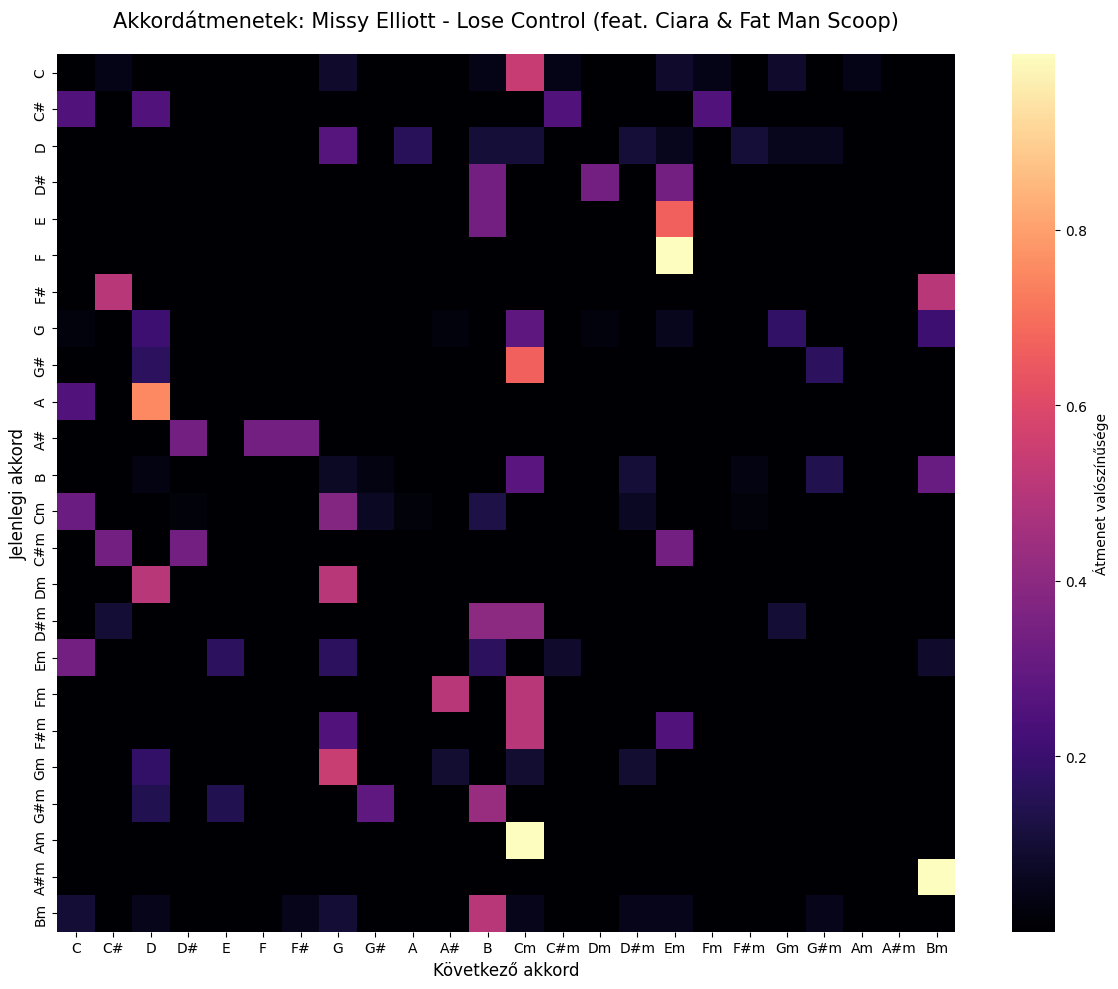

In [25]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- ÚTVONAL ---
H5_PATH = "../Dataset/spotify_dataset_compressed.h5"

def visualize_markov_matrix(track_index=0):
    with h5py.File(H5_PATH, "r") as hf:
        if "features/markov_chords" not in hf:
            print("❌ Hiba: Még nem generáltál Markov-mátrixokat!")
            return
        
        # 1. Adat beolvasása és visszalakítása 24x24-es mátrixszá
        vector = hf["features/markov_chords"][track_index]
        matrix = vector.reshape(24, 24)
        
        # Ha a dal neve is megvan, lekérjük a címnek
        try:
            track_name = hf["tracks/track_name"][track_index].decode('utf-8')
            artist_name = hf["tracks/artist_name"][track_index].decode('utf-8')
            title = f"Akkordátmenetek: {artist_name} - {track_name}"
        except:
            title = f"Akkordátmenetek (Dal index: {track_index})"

    # 2. Akkord nevek előkészítése a tengelyekhez
    notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    labels = [f"{n}" for n in notes] + [f"{n}m" for n in notes]

    # 3. Megjelenítés beállítása
    plt.figure(figsize=(12, 10))
    
    # Maszkoljuk a pici (simított) értékeket, hogy csak a valódi váltások látszódjanak tisztán
    # A 'viridis' vagy 'magma' színséma nagyon jól mutat sötét módban
    sns.heatmap(matrix, 
                annot=False, 
                xticklabels=labels, 
                yticklabels=labels, 
                cmap="magma", 
                cbar_kws={'label': 'Átmenet valószínűsége'})

    plt.title(title, fontsize=15, pad=20)
    plt.xlabel("Következő akkord", fontsize=12)
    plt.ylabel("Jelenlegi akkord", fontsize=12)
    
    # Mentés és megjelenítés
    plt.tight_layout()
    plt.savefig("markov_heatmap.png", dpi=300)
    print(f"✅ A hőtérkép elmentve 'markov_heatmap.png' néven.")

# Futtatás az első dalra
visualize_markov_matrix(0)

t-SNE futtatása (ez eltarthat 1-2 percig)...


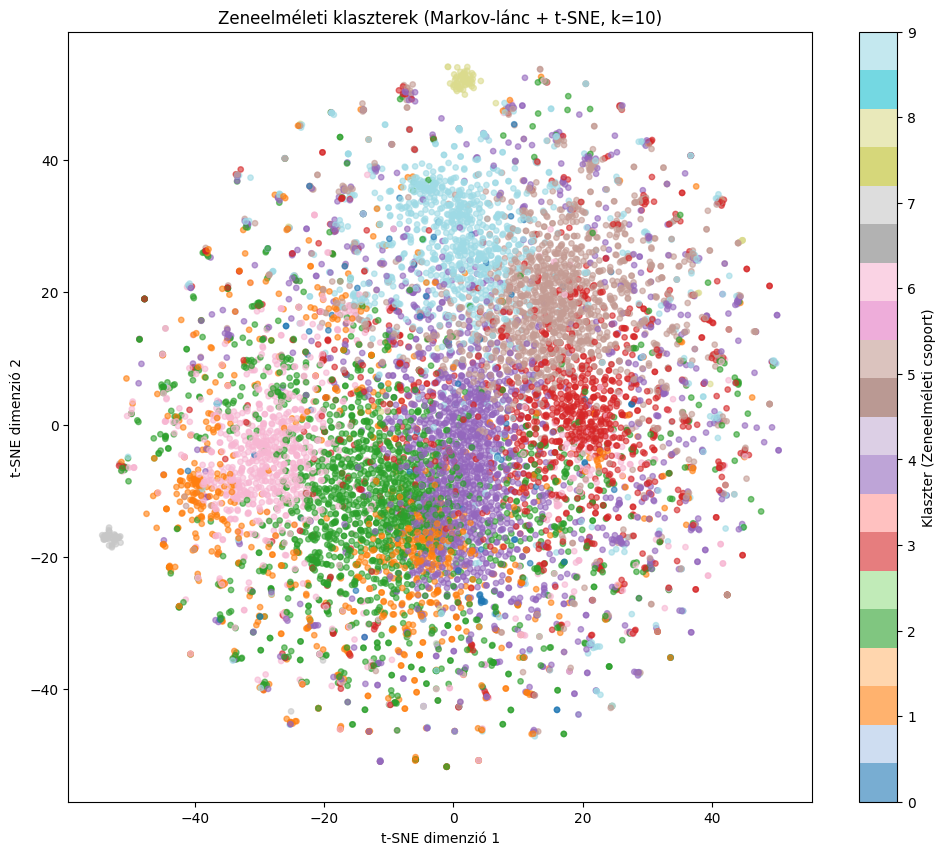

In [27]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. Adatok betöltése a te HDF5 fájlodból
H5_PATH = "../Dataset/spotify_dataset_compressed.h5"
with h5py.File(H5_PATH, "r") as hf:
    # Vegyünk mondjuk 5000 dalt a sebesség kedvéért (a t-SNE lassú)
    data = hf["features/markov_chords"][:10000]
    # Csak azokat, amik nem üresek
    mask = np.sum(data, axis=1) > 0
    vectors = data[mask]

# 2. Skálázás (Nagyon fontos t-SNE és KMeans előtt!)
scaler = StandardScaler()
vectors_scaled = scaler.fit_transform(vectors)

# 3. Klaszterezés (15 csoport, ahogy tervezted)
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(vectors_scaled)

# 4. t-SNE dimenziócsökkentés (Sokkal látványosabb, mint a PCA!)
print("t-SNE futtatása (ez eltarthat 1-2 percig)...")
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
vectors_2d = tsne.fit_transform(vectors_scaled)

# 5. Vizualizáció
plt.figure(figsize=(12, 10))
scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                      c=cluster_labels, cmap='tab20', alpha=0.6, s=15)

plt.colorbar(scatter, label="Klaszter (Zeneelméleti csoport)")
plt.title(f"Zeneelméleti klaszterek (Markov-lánc + t-SNE, k={n_clusters})")
plt.xlabel("t-SNE dimenzió 1")
plt.ylabel("t-SNE dimenzió 2")
plt.show()

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from collections import Counter

# --- Beállítások ---
H5_PATH = "../Dataset/spotify_dataset_compressed.h5"
N_CLUSTERS = 10
N_SAMPLES = 10000  # Az első 10 ezer dalt nézzük a gyorsaságért

print(f"1. Adatok és metaadatok betöltése (első {N_SAMPLES} dal)...")
with h5py.File(H5_PATH, "r") as hf:
    # Markov vektorok betöltése
    raw_data = hf["features/markov_chords"][:N_SAMPLES]
    
    # Metaadatok betöltése
    raw_names = hf["tracks/track_name"][:N_SAMPLES]
    raw_artists = hf["tracks/artist_name"][:N_SAMPLES]
    
    # 2. Szűrés: Csak azokat a dalokat tartsuk meg, amiknek van zenei tartalmuk
    mask = np.sum(raw_data, axis=1) > 0
    vectors = raw_data[mask]
    
    # Metaadatok dekódolása és szűrése a maszk alapján
    names = [n.decode('utf-8') if isinstance(n, bytes) else n for n in raw_names[mask]]
    artists = [a.decode('utf-8') if isinstance(a, bytes) else a for n, a in zip(raw_names[mask], raw_artists[mask])]
    full_titles = [f"{a} - {n}" for a, n in zip(artists, names)]

print(f"   Feldolgozható dalok száma: {len(vectors)}")

# 3. Skálázás
scaler = StandardScaler()
vectors_scaled = scaler.fit_transform(vectors)

# 4. Klaszterezés (K-Means)
print(f"2. Klaszterezés {N_CLUSTERS} csoportba...")
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(vectors_scaled)

# 5. t-SNE dimenziócsökkentés a grafikonhoz
# print("3. t-SNE futtatása a vizualizációhoz (ez eltarthat egy kis ideig)...")
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# vectors_2d = tsne.fit_transform(vectors_scaled)

# 6. Vizualizáció
# plt.figure(figsize=(12, 8))
# scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
#                       c=cluster_labels, cmap='tab20', alpha=0.6, s=10)
# plt.colorbar(scatter, label="Klaszter ID")
# plt.title(f"Zeneelméleti klaszterek (Chord Markov + t-SNE)\nMintavétel: {len(vectors)} dal")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.show()

# 7. Eredmények elemzése: Leggyakoribb előadók klaszterenként
print("\n" + "="*70)
print("📊 ZENEELMÉLETI KLASZTEREK ELEMZÉSE (Chord Transitions)")
print("="*70)

for i in range(N_CLUSTERS):
    # Az adott klaszterbe tartozó indexek
    indices = np.where(cluster_labels == i)[0]
    
    if len(indices) == 0: continue
    
    # Klaszterhez tartozó előadók és dalok
    cluster_artists = [artists[idx] for idx in indices]
    cluster_songs = [full_titles[idx] for idx in indices]
    
    # Statisztika
    artist_counts = Counter(cluster_artists).most_common(5)
    
    print(f"\n📂 KLASZTER #{i:02d} ({len(indices)} dal)")
    print(f"   🔝 Jellemző előadók: {', '.join([f'{a} ({c}x)' for a, c in artist_counts])}")
    print(f"   🎵 Példa dalok:")
    for s in cluster_songs[:5]:
        print(f"      - {s}")
    print("-" * 70)

1. Adatok és metaadatok betöltése (első 10000 dal)...
   Feldolgozható dalok száma: 10000
2. Klaszterezés 10 csoportba...

📊 ZENEELMÉLETI KLASZTEREK ELEMZÉSE (Chord Transitions)

📂 KLASZTER #00 (80 dal)
   🔝 Jellemző előadók: Twenty One Pilots (3x), blackbear (2x), Chris Brown (2x), Pyotr Ilyich Tchaikovsky (2x), Boston (1x)
   🎵 Példa dalok:
      - Boston - Peace of Mind
      - Vansire - Driftless
      - Mark Chesnutt - Goin' Through The Big D
      - blackbear - make daddy proud
      - Zero 7 - In The Waiting Line
----------------------------------------------------------------------

📂 KLASZTER #01 (870 dal)
   🔝 Jellemző előadók: Twenty One Pilots (5x), DJ Khaled (5x), Justin Bieber (5x), Kevin Gates (5x), Usher (4x)
   🎵 Példa dalok:
      - Britney Spears - Toxic
      - Usher - My Boo
      - Nelly Furtado - Promiscuous
      - Daniel Tidwell - Pokémon Theme
      - Collective Soul - Shine
----------------------------------------------------------------------

📂 KLASZTER #02

1. Adatok betöltése és átlagolása...
2. Hőtérkép (Heatmap) generálása...


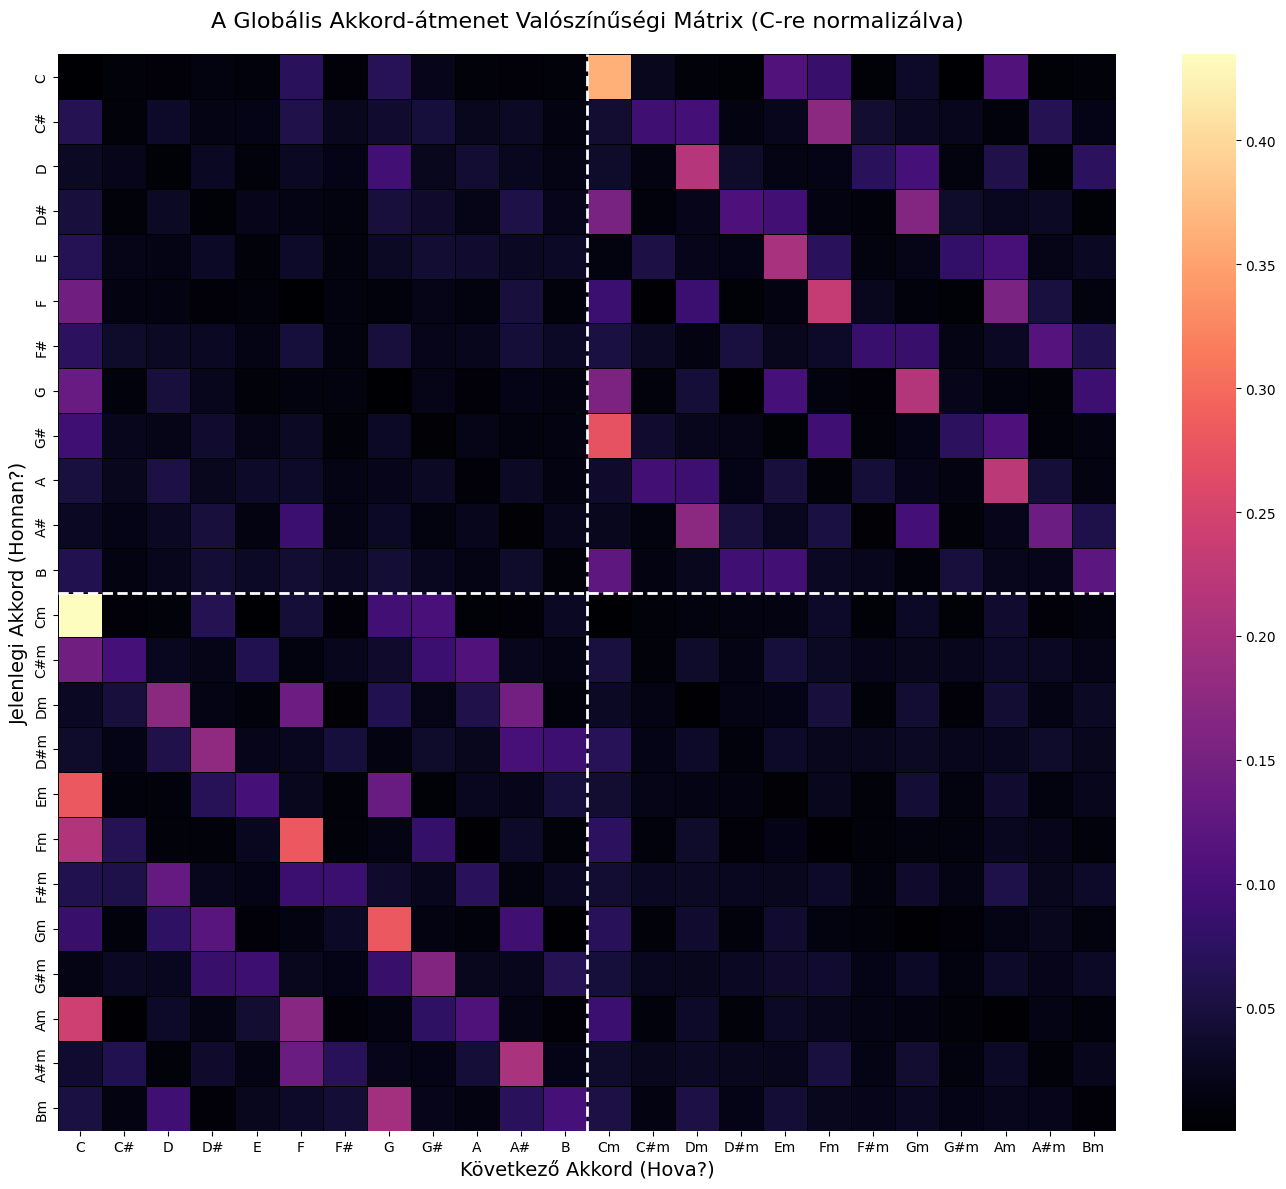

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- BEÁLLÍTÁS ---
H5_FILE = "../Dataset/spotify_dataset_compressed.h5"

# Akkord nevek a tengelyekhez (0-11 Dúr, 12-23 Moll)
CHORDS = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B",
          "Cm", "C#m", "Dm", "D#m", "Em", "Fm", "F#m", "Gm", "G#m", "Am", "A#m", "Bm"]

def plot_average_markov(hdf5_path):
    print("1. Adatok betöltése és átlagolása...")
    with h5py.File(hdf5_path, "r") as hf:
        if "features/markov_chords" not in hf:
            print("❌ Hiba: Nem találom a Markov mátrixokat a fájlban!")
            return
            
        markov_ds = hf["features/markov_chords"]
        
        # Mivel a mátrixok (N, 576) alakban vannak lapítva, átlagoljuk a teljes oszlopokat
        # A np.mean() gyorsan megcsinálja a több ezer dal átlagolását
        mean_vector = np.mean(markov_ds[:], axis=0)
        
        # Visszaalakítjuk 24x24-es mátrixszá
        avg_matrix = mean_vector.reshape((24, 24))

    print("2. Hőtérkép (Heatmap) generálása...")
    plt.figure(figsize=(14, 12))
    
    # Heatmap rajzolása
    sns.heatmap(avg_matrix, 
                xticklabels=CHORDS, 
                yticklabels=CHORDS, 
                cmap="magma", # A sötét-lila-narancs-sárga színskála nagyon jól mutatja a kiugró értékeket
                linewidths=.5, 
                linecolor='black')
    
    plt.title("A Globális Akkord-átmenet Valószínűségi Mátrix (C-re normalizálva)", fontsize=16, pad=20)
    plt.ylabel("Jelenlegi Akkord (Honnan?)", fontsize=14)
    plt.xlabel("Következő Akkord (Hova?)", fontsize=14)
    
    # Kiemeljük a Dúr és Moll közötti határokat egy vizuális vonallal
    plt.axhline(12, color='white', linestyle='--', lw=2)
    plt.axvline(12, color='white', linestyle='--', lw=2)
    
    plt.tight_layout()
    plt.show()

# Futtatás
if __name__ == "__main__":
    plot_average_markov(H5_FILE)

# Markov továbbfejelsztése

In [2]:
import numpy as np
import h5py
from tqdm.notebook import tqdm
from scipy.signal import medfilt # <--- ÚJ IMPORT A SZŰRÉSHEZ

# --- PARAMÉTEREK ÉS ÚTVONALAK ---
H5_FILE = "../Dataset/spotify_dataset_compressed.h5"

def normalize_to_c(chord_seq):
    """
    Egy 0-23 közötti akkordsorozatot (0-11 Dúr, 12-23 Moll) transzponál úgy, 
    hogy a dal alaphangneme (a leggyakoribb akkord) C (0) vagy Cm (12) legyen.
    """
    if len(chord_seq) == 0:
        return chord_seq
        
    # 1. Melyik a leggyakoribb akkord? (Feltételezzük, hogy ez a hangnem)
    counts = np.bincount(chord_seq, minlength=24)
    tonic_idx = np.argmax(counts)
    
    root_note = tonic_idx % 12  # A gyökérhang (0=C, 1=C#, ..., 11=B)
    
    # 2. Kiszámoljuk az eltolást (mennyit kell lépni, hogy C legyen)
    shift = (0 - root_note) % 12
    
    # 3. Eltolás alkalmazása minden akkordra
    normalized_seq = np.zeros_like(chord_seq)
    
    # Külön kezeljük a dúr és moll akkordokat, hogy a saját tartományukban maradjanak
    is_minor = chord_seq >= 12
    
    # Dúr akkordok eltolása (0-11 tartományban pörögnek körbe)
    normalized_seq[~is_minor] = (chord_seq[~is_minor] + shift) % 12
    
    # Moll akkordok eltolása (12-23 tartományban pörögnek körbe)
    normalized_seq[is_minor] = ((chord_seq[is_minor] - 12 + shift) % 12) + 12
    
    return normalized_seq

def run_markov_generation(hdf5_path):
    # 1. Sablonok létrehozása (24 akkord x 12 hang)
    templates = np.zeros((24, 12), dtype=np.float32)
    for i in range(12):
        templates[i, [i, (i + 4) % 12, (i + 7) % 12]] = 1.0 # Dúr
        templates[i + 12, [i, (i + 3) % 12, (i + 7) % 12]] = 1.0 # Moll
    
    templates /= (np.linalg.norm(templates, axis=1, keepdims=True) + 1e-8)

    with h5py.File(hdf5_path, "r+") as hf:
        if "spectrograms/chroma" not in hf:
            print("❌ Hiba: Nem találom a 'spectrograms/chroma' datasetet!")
            return
            
        chroma_ds = hf["spectrograms/chroma"]
        total_tracks = chroma_ds.shape[0]

        # 2. DATASET ELLENŐRZÉSE ÉS ÁTMÉRETEZÉSE
        if "features/markov_chords" not in hf:
            # Ha még nincs, létrehozzuk a teljes méretben
            hf.create_dataset("features/markov_chords", 
                              shape=(total_tracks, 576), 
                              maxshape=(None, 576), # Hogy később is bővíthető legyen
                              dtype=np.float32)
            print("✅ 'features/markov_chords' létrehozva.")
        
        markov_ds = hf["features/markov_chords"]

        # Ha a dataset létezik, de 0 soros vagy kisebb, mint kellene, átméretezzük
        if markov_ds.shape[0] < total_tracks:
            print(f"🔄 Dataset átméretezése: {markov_ds.shape[0]} -> {total_tracks} sorra...")
            markov_ds.resize((total_tracks, 576))

        print(f"🚀 Feldolgozás indítása: {total_tracks} dal...")

        for i in tqdm(range(total_tracks), desc="Akkord-analízis"):
            chroma = chroma_ds[i]
            
            # Időpillanatonkénti normalizálás
            norm = np.linalg.norm(chroma, axis=0, keepdims=True) + 1e-8
            chroma_n = chroma / norm
            
            # Sablonillesztés
            sims = np.dot(templates, chroma_n)
            
            # Nyers akkord sorozat (tele apró "zajos" ugrásokkal)
            chord_seq = np.argmax(sims, axis=0)

            # --- ÚJ RÉSZ: MÉDIA SZŰRŐ (MEDIAN FILTER) ---
            # Kisimítja a milliszekundumos ugrálásokat. 
            # A 21-es kernel méret kb. fél másodperces időablakot jelent.
            chord_seq = medfilt(chord_seq, kernel_size=21).astype(int)
            # --------------------------------------------

            # Alaphangnemre normalizálás
            chord_seq = normalize_to_c(chord_seq)

            # Csak a tényleges akkordváltásokat tartjuk meg
            changes = chord_seq[np.insert(np.diff(chord_seq) != 0, 0, True)]
            
            # Markov-mátrix építése
            m = np.zeros((24, 24), dtype=np.float32) + 1e-5
            
            if len(changes) > 1:
                for current, next_chord in zip(changes[:-1], changes[1:]):
                    m[current, next_chord] += 1
            
            m /= m.sum(axis=1, keepdims=True)
            
            # Mentés
            markov_ds[i] = m.flatten()

    print(f"✨ KÉSZ! Minden adat mentve.")

# Futtatás
run_markov_generation(H5_FILE)

🚀 Feldolgozás indítása: 27052 dal...


Akkord-analízis:   0%|          | 0/27052 [00:00<?, ?it/s]

C:\Users\Béres Gábor\AppData\Local\Temp\ipykernel_15352\3802072540.py:80: RuntimeWarning: invalid value encountered in divide
  chroma_n = chroma / norm


✨ KÉSZ! Minden adat mentve.


1. Adatok betöltése és átlagolása...
2. Hőtérkép (Heatmap) generálása...


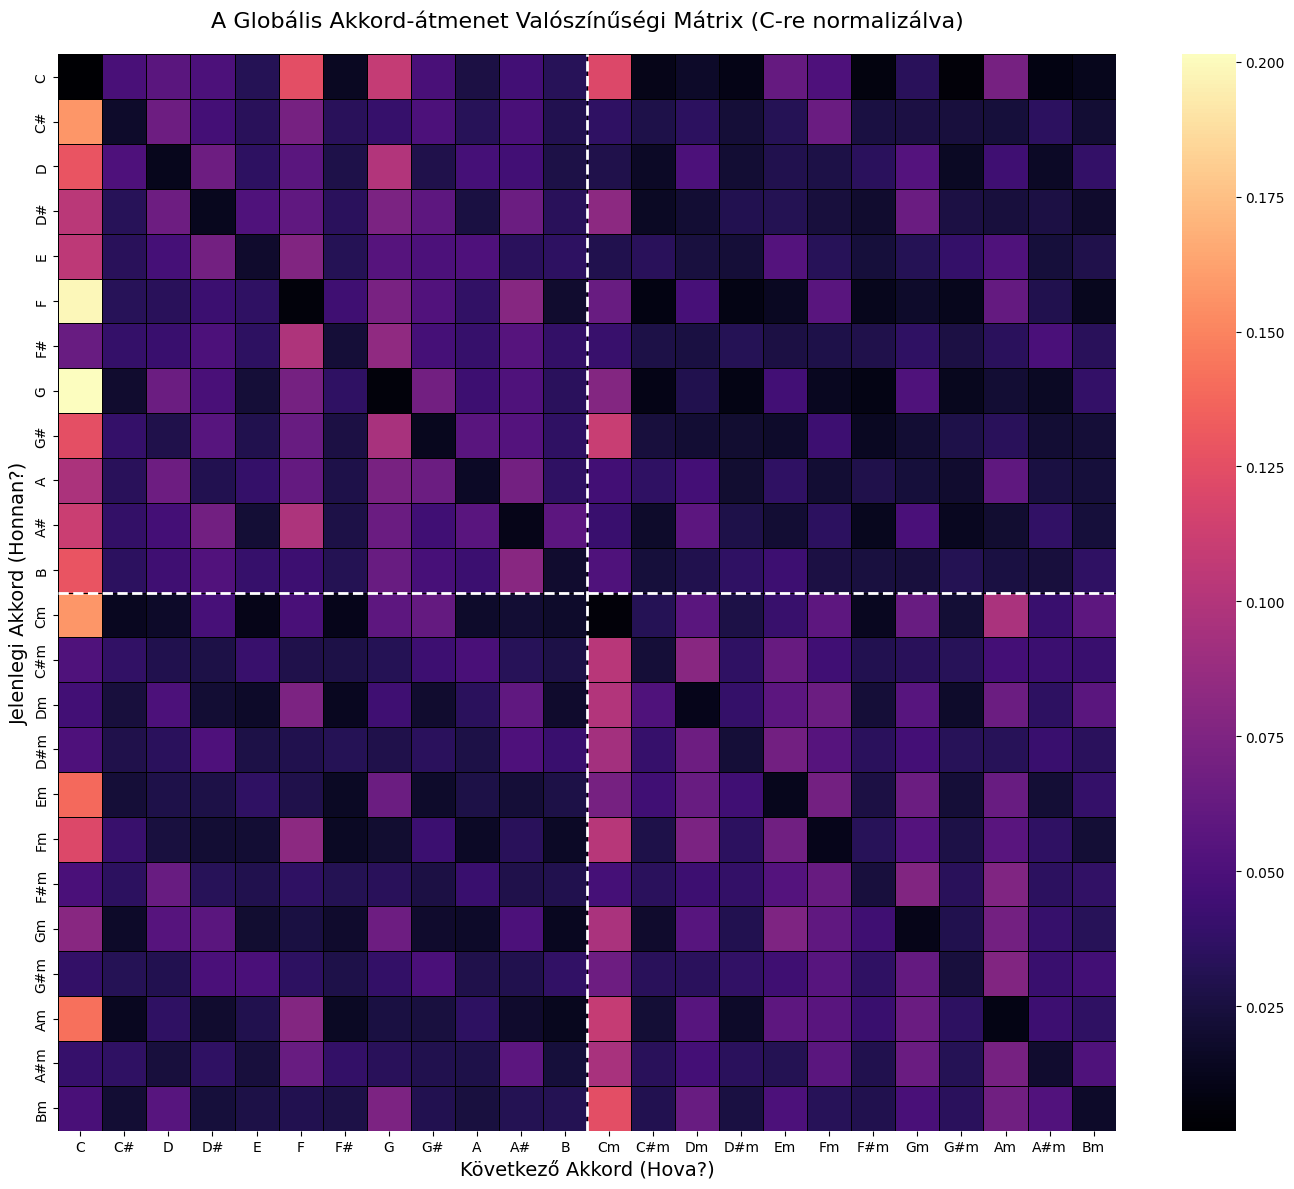

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- BEÁLLÍTÁS ---
H5_FILE = "../Dataset/spotify_dataset_compressed.h5"

# Akkord nevek a tengelyekhez (0-11 Dúr, 12-23 Moll)
CHORDS = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B",
          "Cm", "C#m", "Dm", "D#m", "Em", "Fm", "F#m", "Gm", "G#m", "Am", "A#m", "Bm"]

def plot_average_markov(hdf5_path):
    print("1. Adatok betöltése és átlagolása...")
    with h5py.File(hdf5_path, "r") as hf:
        if "features/markov_chords" not in hf:
            print("❌ Hiba: Nem találom a Markov mátrixokat a fájlban!")
            return
            
        markov_ds = hf["features/markov_chords"]
        
        # Mivel a mátrixok (N, 576) alakban vannak lapítva, átlagoljuk a teljes oszlopokat
        # A np.mean() gyorsan megcsinálja a több ezer dal átlagolását
        mean_vector = np.mean(markov_ds[:], axis=0)
        
        # Visszaalakítjuk 24x24-es mátrixszá
        avg_matrix = mean_vector.reshape((24, 24))

    print("2. Hőtérkép (Heatmap) generálása...")
    plt.figure(figsize=(14, 12))
    
    # Heatmap rajzolása
    sns.heatmap(avg_matrix, 
                xticklabels=CHORDS, 
                yticklabels=CHORDS, 
                cmap="magma", # A sötét-lila-narancs-sárga színskála nagyon jól mutatja a kiugró értékeket
                linewidths=.5, 
                linecolor='black')
    
    plt.title("A Globális Akkord-átmenet Valószínűségi Mátrix (C-re normalizálva)", fontsize=16, pad=20)
    plt.ylabel("Jelenlegi Akkord (Honnan?)", fontsize=14)
    plt.xlabel("Következő Akkord (Hova?)", fontsize=14)
    
    # Kiemeljük a Dúr és Moll közötti határokat egy vizuális vonallal
    plt.axhline(12, color='white', linestyle='--', lw=2)
    plt.axvline(12, color='white', linestyle='--', lw=2)
    
    plt.tight_layout()
    plt.show()

# Futtatás
if __name__ == "__main__":
    plot_average_markov(H5_FILE)

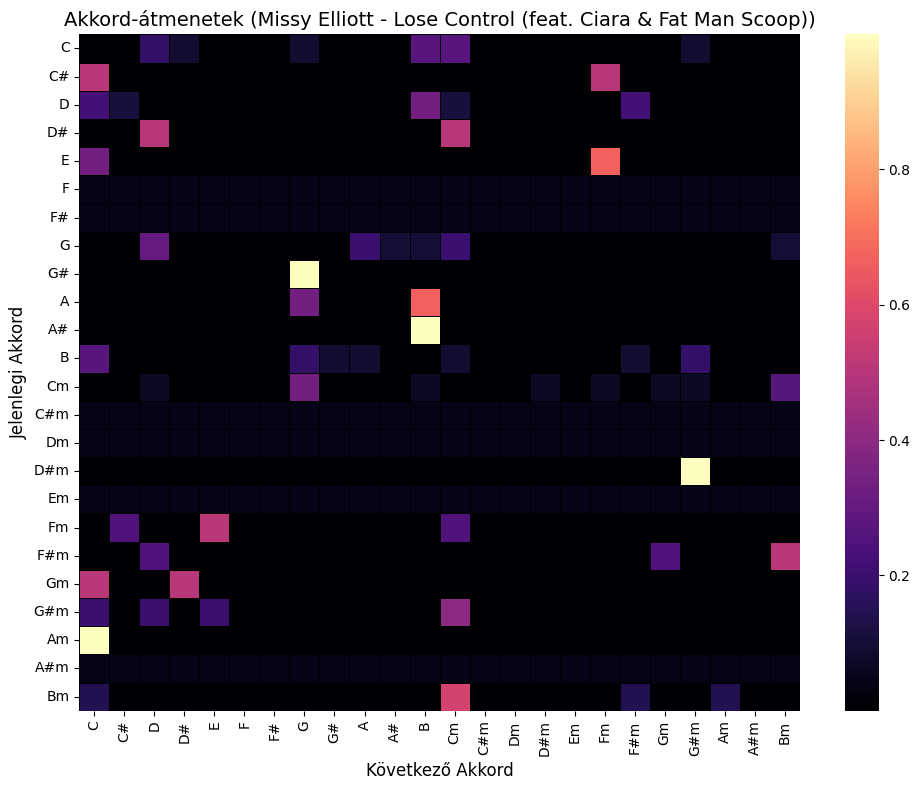

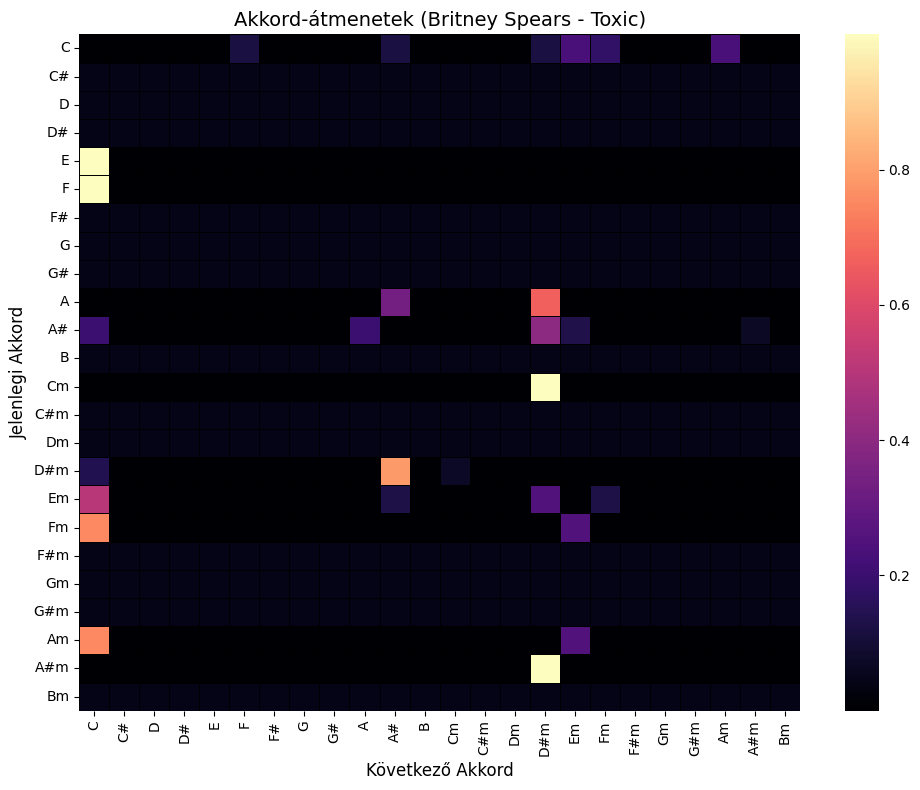

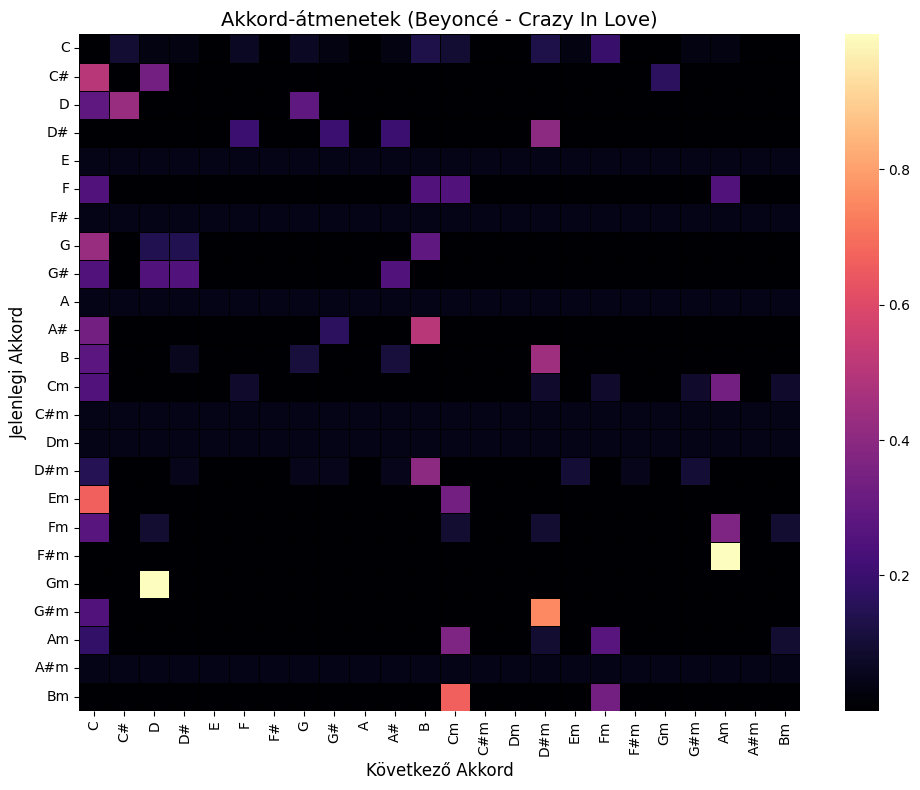

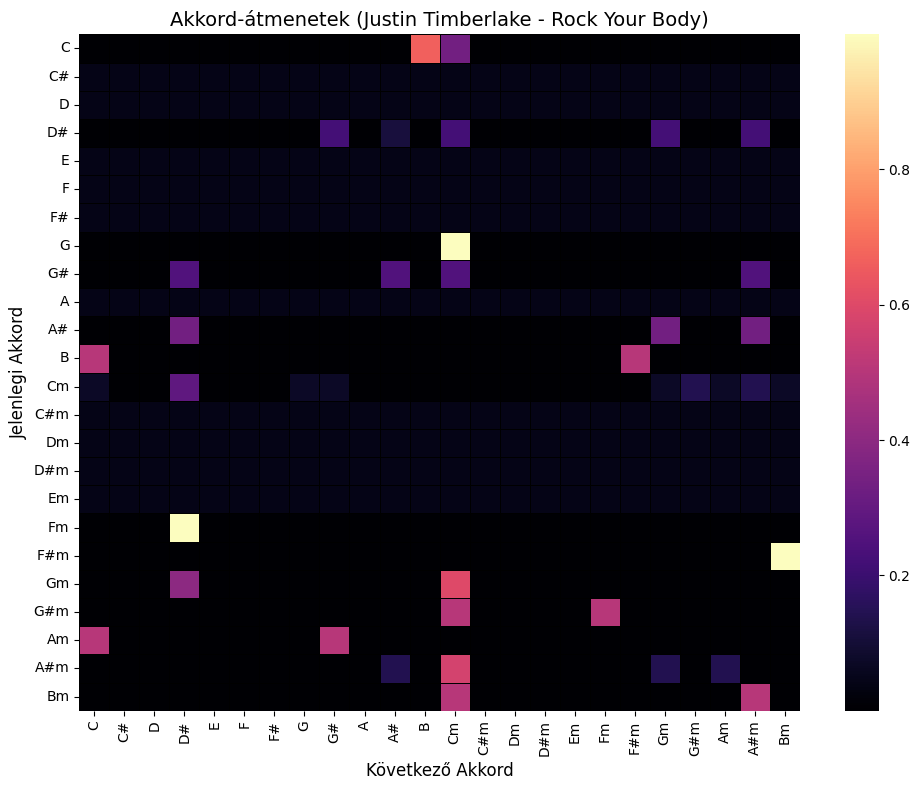

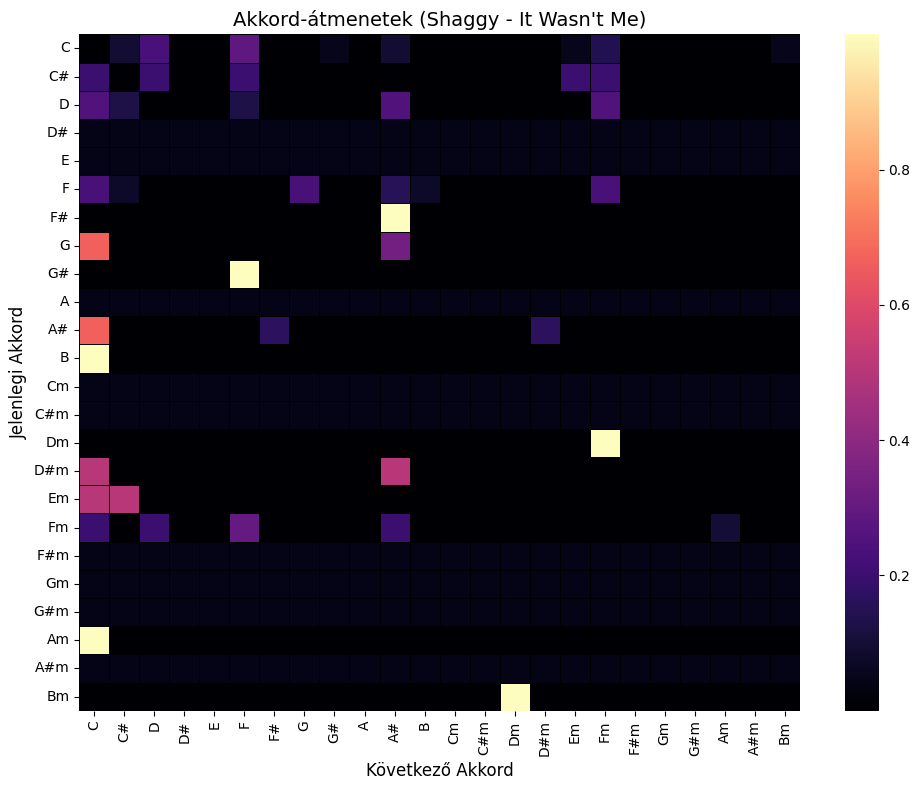

In [8]:
# Első 5 dal akkord átmeneti vektorának megjelenítése hőtérképpel és dal címmel
with h5py.File(H5_FILE, "r") as hf:
    markov_ds = hf["features/markov_chords"]
    for i in range(5):
        vector = markov_ds[i]
        matrix = vector.reshape(24, 24)
        artist_name = hf["tracks/artist_name"][i].decode('utf-8')
        track_name = hf["tracks/track_name"][i].decode('utf-8')
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(matrix, 
                    xticklabels=CHORDS, 
                    yticklabels=CHORDS, 
                    cmap="magma", 
                    linewidths=.5, 
                    linecolor='black')
        
        plt.title(f"Akkord-átmenetek ({artist_name} - {track_name})", fontsize=14)
        plt.ylabel("Jelenlegi Akkord", fontsize=12)
        plt.xlabel("Következő Akkord", fontsize=12)
        plt.tight_layout()
        plt.show()

t-SNE futtatása (ez eltarthat 1-2 percig)...


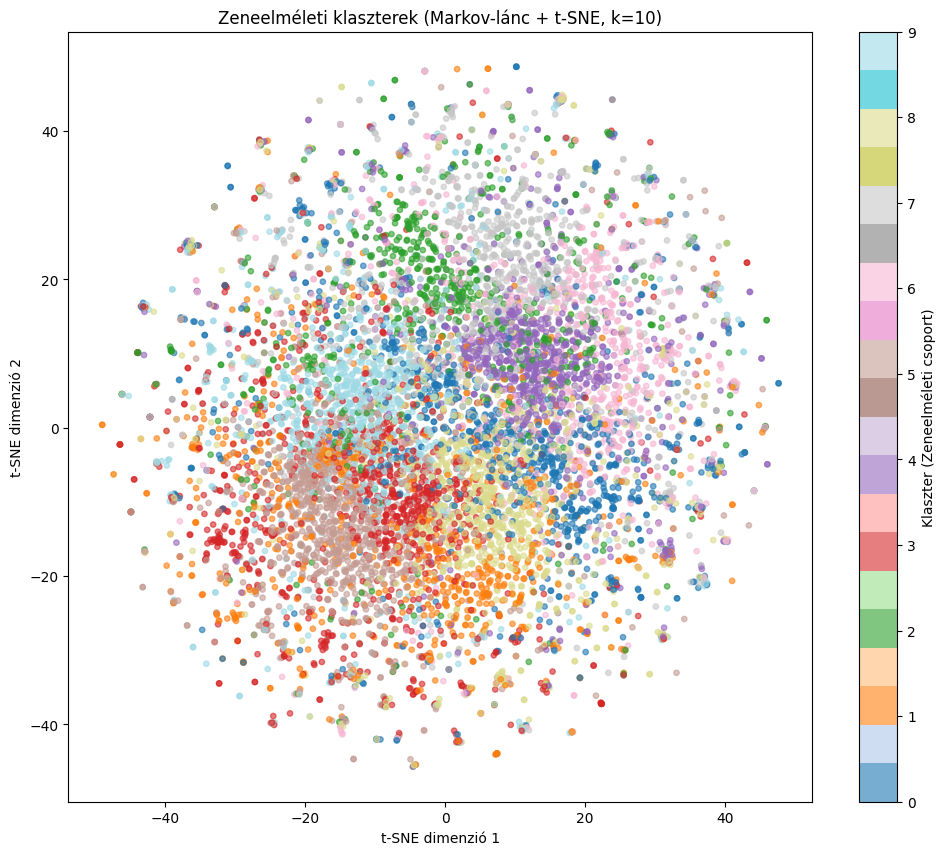

In [9]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. Adatok betöltése a te HDF5 fájlodból
H5_PATH = "../Dataset/spotify_dataset_compressed.h5"
with h5py.File(H5_PATH, "r") as hf:
    # Vegyünk mondjuk 5000 dalt a sebesség kedvéért (a t-SNE lassú)
    data = hf["features/markov_chords"][:10000]
    # Csak azokat, amik nem üresek
    mask = np.sum(data, axis=1) > 0
    vectors = data[mask]

# 2. Skálázás (Nagyon fontos t-SNE és KMeans előtt!)
scaler = StandardScaler()
vectors_scaled = scaler.fit_transform(vectors)

# 3. Klaszterezés (15 csoport, ahogy tervezted)
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(vectors_scaled)

# 4. t-SNE dimenziócsökkentés (Sokkal látványosabb, mint a PCA!)
print("t-SNE futtatása (ez eltarthat 1-2 percig)...")
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
vectors_2d = tsne.fit_transform(vectors_scaled)

# 5. Vizualizáció
plt.figure(figsize=(12, 10))
scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                      c=cluster_labels, cmap='tab20', alpha=0.6, s=15)

plt.colorbar(scatter, label="Klaszter (Zeneelméleti csoport)")
plt.title(f"Zeneelméleti klaszterek (Markov-lánc + t-SNE, k={n_clusters})")
plt.xlabel("t-SNE dimenzió 1")
plt.ylabel("t-SNE dimenzió 2")
plt.show()

In [10]:
import numpy as np
import h5py
from scipy.signal import medfilt

# --- BEÁLLÍTÁSOK ---
H5_FILE = "../Dataset/spotify_dataset_compressed.h5"
NUM_SONGS_TO_CHECK = 3  # Hány dalt írjunk ki az elejéről?

# Idő-kalkulációhoz (Ha Librosa alapbeállítással készültek a spektrogramok)
SR = 22050
HOP_LENGTH = 512
FRAME_DURATION = HOP_LENGTH / SR  # kb. 0.0232 másodperc / frame

# Akkord nevek (0-11 Dúr, 12-23 Moll)
CHORDS = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B",
          "Cm", "C#m", "Dm", "D#m", "Em", "Fm", "F#m", "Gm", "G#m", "Am", "A#m", "Bm"]

def format_time(seconds):
    """Másodperceket Perc:Másodperc.tizedmásodperc formátumba alakít."""
    m = int(seconds // 60)
    s = seconds % 60
    return f"{m}:{s:04.1f}"

def generate_timeline():
    # 1. Sablonok (Dúr és Moll)
    templates = np.zeros((24, 12), dtype=np.float32)
    for i in range(12):
        templates[i, [i, (i + 4) % 12, (i + 7) % 12]] = 1.0
        templates[i + 12, [i, (i + 3) % 12, (i + 7) % 12]] = 1.0
    templates /= (np.linalg.norm(templates, axis=1, keepdims=True) + 1e-8)

    with h5py.File(H5_FILE, "r") as hf:
        chroma_ds = hf["spectrograms/chroma"]
        uris = hf["ml/track_uri"]
        
        print("🔍 AKKORD IDŐVONAL ELLENŐRZÉS 🔍\n" + "="*40)
        
        for i in range(min(NUM_SONGS_TO_CHECK, chroma_ds.shape[0])):
            uri = uris[i].decode('utf-8') if isinstance(uris[i], bytes) else uris[i]
            chroma = chroma_ds[i]
            
            # Kinyerés és Szűrés
            norm = np.linalg.norm(chroma, axis=0, keepdims=True) + 1e-8
            chroma_n = chroma / norm
            sims = np.dot(templates, chroma_n)
            
            # Nyers akkordok -> Média szűrő
            chord_seq = np.argmax(sims, axis=0)
            chord_seq = medfilt(chord_seq, kernel_size=21).astype(int)
            
            # --- IDŐVONAL FELDOLGOZÁSA ---
            print(f"\n🎵 DAL {i+1} URI: {uri}")
            print("-" * 40)
            
            current_chord = chord_seq[0]
            start_frame = 0
            
            for frame_idx, chord in enumerate(chord_seq):
                if chord != current_chord:
                    # Akkordváltás történt! Kiírjuk az előző szakaszt.
                    start_time = start_frame * FRAME_DURATION
                    end_time = frame_idx * FRAME_DURATION
                    
                    # Csak a fél másodpercnél hosszabb szakaszokat írjuk ki, hogy olvasható maradjon
                    if (end_time - start_time) > 0.5:
                        print(f"[{format_time(start_time)} - {format_time(end_time)}] ➡️ {CHORDS[current_chord]}")
                    
                    current_chord = chord
                    start_frame = frame_idx
            
            # Utolsó akkord kiírása a dal végéig
            start_time = start_frame * FRAME_DURATION
            end_time = len(chord_seq) * FRAME_DURATION
            if (end_time - start_time) > 0.5:
                print(f"[{format_time(start_time)} - {format_time(end_time)}] ➡️ {CHORDS[current_chord]}")
            
            print("="*40)

if __name__ == "__main__":
    generate_timeline()

🔍 AKKORD IDŐVONAL ELLENŐRZÉS 🔍

🎵 DAL 1 URI: spotify:track:7mG2RbhyzGsjpQOz568d39
----------------------------------------
[0:00.0 - 0:00.7] ➡️ F#
[0:01.0 - 0:02.5] ➡️ Gm
[0:02.5 - 0:03.0] ➡️ D
[0:03.3 - 0:03.9] ➡️ D
[0:04.0 - 0:05.4] ➡️ F#
[0:06.8 - 0:08.2] ➡️ Gm
[0:08.4 - 0:09.1] ➡️ D
[0:09.2 - 0:09.8] ➡️ D
[0:09.9 - 0:11.3] ➡️ F#
[0:11.3 - 0:12.1] ➡️ Gm
[0:12.9 - 0:14.3] ➡️ Gm
[0:14.3 - 0:14.9] ➡️ D
[0:15.3 - 0:15.8] ➡️ D
[0:16.1 - 0:17.2] ➡️ F#
[0:18.2 - 0:18.9] ➡️ F#
[0:18.9 - 0:20.0] ➡️ Gm
[0:21.7 - 0:23.2] ➡️ F#
[0:23.3 - 0:24.5] ➡️ Gm
[0:27.7 - 0:28.2] ➡️ A
[0:28.2 - 0:28.8] ➡️ Dm

🎵 DAL 2 URI: spotify:track:6ipPdKoiZz0dEB7eGj55oR
----------------------------------------
[0:00.1 - 0:02.3] ➡️ A
[0:03.1 - 0:04.5] ➡️ A
[0:04.5 - 0:05.9] ➡️ A
[0:06.3 - 0:07.1] ➡️ A
[0:07.6 - 0:10.0] ➡️ A
[0:10.2 - 0:10.8] ➡️ A
[0:11.4 - 0:12.3] ➡️ A
[0:12.7 - 0:14.2] ➡️ A
[0:14.4 - 0:15.6] ➡️ A
[0:16.4 - 0:17.1] ➡️ Cm
[0:17.6 - 0:18.3] ➡️ Cm
[0:18.9 - 0:19.5] ➡️ G
[0:19.5 - 0:21.0] ➡️ A
[0:21.2 - 0

# Lokális és globális entrópia

In [1]:
import h5py
import numpy as np
import os

DATASET_DIR = "../Dataset/"
OUTPUT_FILE = os.path.join(DATASET_DIR, "spotify_dataset_compressed.h5")

with h5py.File(OUTPUT_FILE, "a") as hf:
    if "features" not in hf:
        feat_grp = hf.create_group("features")
        print("✅ '/features' group létrehozva.")
    else:
        feat_grp = hf["features"]
        print("ℹ️ '/features' group már létezik.")

    # 1. Eredeti Markov mátrix (576 érték)
    if "markov_chords" not in feat_grp:
        feat_grp.create_dataset("markov_chords", shape=(0, 576), maxshape=(None, 576),
                                dtype=np.float32, chunks=(1000, 576), compression="lzf")
        print("✅ 'markov_chords' dataset létrehozva.")

    # ==========================================
    # ÚJ DATASETEK AZ ENTRÓPIÁNAK
    # ==========================================
    
    # 2. Lokális Entrópia (24 érték)
    if "markov_entropy_local" not in feat_grp:
        feat_grp.create_dataset("markov_entropy_local", shape=(0, 24), maxshape=(None, 24),
                                dtype=np.float32, chunks=(1000, 24), compression="lzf")
        print("✅ 'markov_entropy_local' dataset létrehozva.")

    # 3. Globális Entrópia (1 érték)
    if "markov_entropy_global" not in feat_grp:
        feat_grp.create_dataset("markov_entropy_global", shape=(0, 1), maxshape=(None, 1),
                                dtype=np.float32, chunks=(1000, 1), compression="lzf")
        print("✅ 'markov_entropy_global' dataset létrehozva.")

ℹ️ '/features' group már létezik.
✅ 'markov_entropy_local' dataset létrehozva.
✅ 'markov_entropy_global' dataset létrehozva.


In [1]:
import numpy as np
import h5py
from tqdm.notebook import tqdm
from scipy.signal import medfilt
import scipy.stats  # <--- ÚJ IMPORT AZ ENTRÓPIÁHOZ

# --- PARAMÉTEREK ÉS ÚTVONALAK ---
H5_FILE = "../Dataset/spotify_dataset_compressed.h5"

def normalize_to_c(chord_seq):
    """
    Egy 0-23 közötti akkordsorozatot (0-11 Dúr, 12-23 Moll) transzponál úgy, 
    hogy a dal alaphangneme (a leggyakoribb akkord) C (0) vagy Cm (12) legyen.
    """
    if len(chord_seq) == 0:
        return chord_seq
        
    counts = np.bincount(chord_seq, minlength=24)
    tonic_idx = np.argmax(counts)
    root_note = tonic_idx % 12
    shift = (0 - root_note) % 12
    normalized_seq = np.zeros_like(chord_seq)
    is_minor = chord_seq >= 12
    normalized_seq[~is_minor] = (chord_seq[~is_minor] + shift) % 12
    normalized_seq[is_minor] = ((chord_seq[is_minor] - 12 + shift) % 12) + 12
    return normalized_seq

def run_markov_generation(hdf5_path):
    # 1. Sablonok létrehozása (24 akkord x 12 hang)
    templates = np.zeros((24, 12), dtype=np.float32)
    for i in range(12):
        templates[i, [i, (i + 4) % 12, (i + 7) % 12]] = 1.0 # Dúr
        templates[i + 12, [i, (i + 3) % 12, (i + 7) % 12]] = 1.0 # Moll
    templates /= (np.linalg.norm(templates, axis=1, keepdims=True) + 1e-8)

    with h5py.File(hdf5_path, "r+") as hf:
        if "spectrograms/chroma" not in hf:
            print("❌ Hiba: Nem találom a 'spectrograms/chroma' datasetet!")
            return
            
        chroma_ds = hf["spectrograms/chroma"]
        total_tracks = chroma_ds.shape[0]
        feat_grp = hf["features"]

        # 2. DATASETEK ÁTMÉRETEZÉSE (Mátrix + Entrópiák)
        markov_ds = feat_grp["markov_chords"]
        if markov_ds.shape[0] < total_tracks: markov_ds.resize((total_tracks, 576))
            
        entropy_local_ds = feat_grp["markov_entropy_local"]
        if entropy_local_ds.shape[0] < total_tracks: entropy_local_ds.resize((total_tracks, 24))
            
        entropy_global_ds = feat_grp["markov_entropy_global"]
        if entropy_global_ds.shape[0] < total_tracks: entropy_global_ds.resize((total_tracks, 1))

        print(f"🚀 Feldolgozás indítása: {total_tracks} dal...")

        for i in tqdm(range(total_tracks), desc="Akkord-analízis"):
            chroma = chroma_ds[i]
            
            # Időpillanatonkénti normalizálás
            norm = np.linalg.norm(chroma, axis=0, keepdims=True) + 1e-8
            chroma_n = chroma / norm
            
            # Sablonillesztés
            sims = np.dot(templates, chroma_n)
            
            # Nyers akkord sorozat
            chord_seq = np.argmax(sims, axis=0)

            # Média szűrő (Median Filter) - zajszűrés
            chord_seq = medfilt(chord_seq, kernel_size=21).astype(int)

            # Alaphangnemre normalizálás
            chord_seq = normalize_to_c(chord_seq)

            # Csak a tényleges akkordváltásokat tartjuk meg
            changes = chord_seq[np.insert(np.diff(chord_seq) != 0, 0, True)]
            
            # Markov-mátrix építése
            m = np.zeros((24, 24), dtype=np.float32) + 1e-5
            chord_counts = np.zeros(24, dtype=np.float32) # Entrópia súlyozáshoz
            
            if len(changes) > 1:
                for current, next_chord in zip(changes[:-1], changes[1:]):
                    m[current, next_chord] += 1
                    chord_counts[current] += 1
            
            # Normalizálás: sorok összege 1 legyen
            m /= m.sum(axis=1, keepdims=True)
            
            # --- ENTRÓPIA SZÁMÍTÁS ---
            # 1. Lokális entrópia
            local_entropy = scipy.stats.entropy(m, base=2, axis=1)
            
            # 2. Globális entrópia (súlyozott átlag)
            total_transitions = np.sum(chord_counts)
            if total_transitions > 0:
                weights = chord_counts / total_transitions
                global_entropy = np.sum(local_entropy * weights)
            else:
                global_entropy = 0.0
            
            # --- MENTÉS A HDF5-BE ---
            markov_ds[i] = m.flatten()
            entropy_local_ds[i] = local_entropy
            entropy_global_ds[i] = np.array([global_entropy])

    print(f"✨ KÉSZ! Minden adat mentve.")

# Futtatás
run_markov_generation(H5_FILE)

🚀 Feldolgozás indítása: 27052 dal...


Akkord-analízis:   0%|          | 0/27052 [00:00<?, ?it/s]

C:\Users\Béres Gábor\AppData\Local\Temp\ipykernel_12844\3936580596.py:62: RuntimeWarning: invalid value encountered in divide
  chroma_n = chroma / norm


✨ KÉSZ! Minden adat mentve.


In [4]:
import h5py
import numpy as np

# --- BEÁLLÍTÁSOK ---
H5_FILE = "../Dataset/spotify_dataset_compressed.h5"
NUM_SONGS_TO_CHECK = 10  # Hány dalt nézzünk meg?

CHORDS = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B",
          "Cm", "C#m", "Dm", "D#m", "Em", "Fm", "F#m", "Gm", "G#m", "Am", "A#m", "Bm"]

def check_entropies():
    with h5py.File(H5_FILE, "r") as hf:
        uris = hf["ml/track_uri"]
        local_ds = hf["features/markov_entropy_local"]
        global_ds = hf["features/markov_entropy_global"]
        
        print("🔍 ENTRÓPIA ELLENŐRZÉS 🔍\n" + "="*50)
        
        for i in range(min(NUM_SONGS_TO_CHECK, uris.shape[0])):
            uri = uris[i].decode('utf-8') if isinstance(uris[i], bytes) else uris[i]
            g_ent = global_ds[i][0]
            l_ent = local_ds[i]
            
            print(f"🎵 Dal {i+1} URI: {uri}")
            print(f"🌍 Globális Entrópia: {g_ent:.4f} bit")
            
            # Csak a ténylegesen megszólaló akkordok lokális entrópiáját írjuk ki
            active_chords = []
            for j, ent in enumerate(l_ent):
                # A 4.58 bit a maximum (egyenletes eloszlás az 1e-5 alapérték miatt)
                if ent < 4.58: 
                    active_chords.append(f"{CHORDS[j]}: {ent:.2f}")
            
            print(f"📍 Lokális Entrópiák (Aktív akkordok):")
            if active_chords:
                # 5 akkordonként új sorba törjük, hogy szép legyen
                for chunk_idx in range(0, len(active_chords), 5):
                    print("   " + " | ".join(active_chords[chunk_idx:chunk_idx+5]))
            else:
                print("   Nincs értékelhető aktív akkord.")
                
            print("-" * 50)

if __name__ == "__main__":
    check_entropies()

🔍 ENTRÓPIA ELLENŐRZÉS 🔍
🎵 Dal 1 URI: spotify:track:7mG2RbhyzGsjpQOz568d39
🌍 Globális Entrópia: 1.9991 bit
📍 Lokális Entrópiák (Aktív akkordok):
   C: 2.41 | C#: 1.00 | D: 2.20 | D#: 1.00 | E: 0.92
   G: 2.45 | G#: 0.00 | A: 0.92 | A#: 0.00 | B: 2.66
   Cm: 2.60 | D#m: 0.00 | Fm: 1.50 | F#m: 1.50 | Gm: 1.00
   G#m: 1.92 | Am: 0.00 | Bm: 1.67
--------------------------------------------------
🎵 Dal 2 URI: spotify:track:6ipPdKoiZz0dEB7eGj55oR
🌍 Globális Entrópia: 1.5836 bit
📍 Lokális Entrópiák (Aktív akkordok):
   C: 2.51 | E: 0.00 | F: 0.00 | A: 0.92 | A#: 2.11
   Cm: 0.00 | D#m: 0.95 | Em: 1.75 | Fm: 0.81 | Am: 0.81
   A#m: 0.00
--------------------------------------------------
🎵 Dal 3 URI: spotify:track:3bA30uvYoSwHYFW4IOO2O4
🌍 Globális Entrópia: 2.2876 bit
📍 Lokális Entrópiák (Aktív akkordok):
   C: 3.50 | C#: 1.46 | D: 1.56 | D#: 1.92 | F: 2.00
   G: 1.84 | G#: 2.00 | A#: 1.46 | B: 1.97 | Cm: 2.52
   D#m: 2.68 | Em: 0.92 | Fm: 2.30 | F#m: 0.00 | Gm: 0.00
   G#m: 0.81 | Am: 2.12 | Bm

In [5]:
import h5py

OLD_FILE = "../Dataset/spotify_dataset_compressed.h5"
NEW_FILE = "../Dataset/spotify_dataset_lite.h5"

with h5py.File(OLD_FILE, 'r') as hf_old, h5py.File(NEW_FILE, 'w') as hf_new:
    for group_name in hf_old.keys():
        hf_new.create_group(group_name)
        for ds_name in hf_old[group_name].keys():
            full_path = f"{group_name}/{ds_name}"
            
            # CSAK ezt hagyja ki
            if full_path == "spectrograms/tempogram":
                continue
                
            # Minden mást másol
            hf_old.copy(full_path, hf_new[group_name])

In [9]:
# HDF5 fájl mérete
import os
print(f"✅ 'spotify_dataset_lite.h5' létrehozva. Méret: {os.path.getsize(NEW_FILE) / (1024**2):.2f} MB")

✅ 'spotify_dataset_lite.h5' létrehozva. Méret: 14851.09 MB
